# Auditing the record before the paper: `eval.py` demo

This notebook runs the **assembly step** of the iteration-3 record audit (`eval.py`). The audit collects no new data. It reads
the result files that earlier artifacts of the run produced, checks them against each other, and writes one
`exp_eval_sol_out` file (`eval_out.json`) with:

* **`metrics_agg`**: the headline numbers. These are claims-ledger status counts, Exp5-vs-Exp6 frame agreement (onset, home
  field, retention kappa), the O5 external-recognition validation (base rate, correlation with publication outcomes, hand-check
  precision), the Exp6 next-field trace, and refit-bootstrap CIs for the iteration-1 deltas.
* **six per-example datasets**: `claims_ledger`, `refit_bootstrap_iter1`, `next_field_trace`,
  `frame_agreement_shared_concepts`, `o5_exp5_frame` and `o5_hand_check`.

The work-package scripts (`wp1_ledger.py` … `wp4_o5.py`) that produce these inputs need the full multi-GB upstream run, so
they are **not** run here. Instead, `mini_demo_data.json` bundles the files that `assemble()` reads:

* all of the small JSON summaries, complete;
* the per-row tables as curated subsets of **at most 100 rows**: all 22 non-MATCH ledger rows plus 78 MATCH rows, all 19
  disagreeing shared concepts plus 81 agreeing ones, 100 O5 concepts stratified by outcome × split, and all 100 hand-check
  items.

The code below is the original `common.py` and `eval.py`, split into cells. The only changes: the workspace path comes from the
config cell, and the CLI argument `--stages` became a config variable. The metrics that come from the JSON summaries match the
full run exactly. The counts that come from the tables describe the subsets.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, scipy, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'matplotlib==3.10.0')

## Imports
These are the original import blocks of `eval.py` and `common.py`, plus `matplotlib` and `types` for the notebook.
`import common as C` is replaced by a namespace that is built after the `common.py` cell below.

In [2]:
# ---- eval.py imports (original)
from __future__ import annotations

import argparse
import json
import math
import subprocess
import sys

import numpy as np
import pandas as pd
from loguru import logger

# ---- common.py imports (original)
import hashlib
import os
from pathlib import Path

from scipy import stats

# ---- notebook-only
import types
import matplotlib.pyplot as plt

## Load the demo data
The data loads from GitHub (Colab) and falls back to a local `mini_demo_data.json`.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8795ea-concepts-spread-once-adopters-make-them/fork/run_ud-q6jnkjLXa/round-3/evaluation-2/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print({k: len(v) for k, v in data["tables"].items()}, "rows (demo subset)")
print(data["full_table_sizes"], "rows (full run)")

Inputs read by eval.py assemble() for the iteration-3 record audit. Small JSON summaries are complete; per-row tables are curated subsets of at most 100 rows. full_run_metrics_agg holds the metrics of the full run.
{'claims_ledger.csv': 100, 'exp5/frame_concepts.csv': 100, 'exp6/results/frame_concepts.csv': 100, 'record_tables/o5_concept_panel.csv': 100, 'record_tables/o5_handcheck_items_final.csv': 100} rows (demo subset)
{'claims_ledger.csv': 246, 'exp5/frame_concepts.csv': 12499, 'exp6/results/frame_concepts.csv': 653, 'shared_concepts': 628, 'record_tables/o5_concept_panel.csv': 12499, 'record_tables/o5_handcheck_items_final.csv': 100} rows (full run)


## Config
`assemble()` has no iterations or epochs. Its only size knobs are how many rows of each input table it reads, so those are the
tunable parameters. `None` means every row in `mini_demo_data.json` (at most 100). The full run used the complete tables:
246 ledger rows, 628 shared frame concepts, 12,499 O5 concepts and 100 hand-check items.

`RUN_STAGES` replaces the original `--stages` CLI flag. `"all"` would re-run the work-package scripts first, which needs the full
upstream run, so the demo leaves it at `""` (assemble only, the script's default).

`DEMO_WS` mirrors the run layout (`<root>/iter_3/gen_art/<this folder>`), so `common.py`'s default `ROOT = WS.parents[2]` and
its upstream paths (`ROOT/iter_2/gen_art/gen_art_experiment_5`, …) resolve inside the demo folder with no edits.

In [5]:
N_LEDGER_ROWS = None       # claims_ledger.csv rows          (demo max 100; full run 246)
N_FRAME_CONCEPTS = None    # shared Exp5/Exp6 frame concepts (demo max 100; full run 628)
N_PANEL_ROWS = None        # O5 concept-panel rows           (demo max 100; full run 12,499)
N_HANDCHECK_ITEMS = None   # O5 hand-check items             (demo max 100; full run 100)
RUN_STAGES = ""            # original CLI: --stages ('' = assemble only, 'all' = rerun every work package first)
DEMO_WS = Path("record_audit_demo/iter_3/gen_art/gen_art_evaluation_2")
DEMO_WS.mkdir(parents=True, exist_ok=True)

## `common.py`: shared paths, ID normaliser, statistics helpers and provenance tracking
This is the original module. One line changed: `WS = Path(__file__).resolve().parent` became `WS = DEMO_WS.resolve()`,
because a notebook has no `__file__`. `ROOT` is the folder that holds the upstream artifacts (`iter_1/…`, `iter_2/…`).
`read_csv` and `read_json` record a sha256 of every input for `inputs_manifest.json`. `norm_id` maps Exp5 integer IDs and Exp6
OpenAlex URLs onto one `C<digits>` form, so the two frames can be joined.

In [6]:
"""Shared paths, ID normaliser, statistics helpers and provenance tracking for the record audit."""
WS = DEMO_WS.resolve()  # original: Path(__file__).resolve().parent
# Root that holds the dependency artifacts (iter_1/..., iter_2/...). Default: the run layout this workspace sits in
# (<root>/iter_3/gen_art/<this folder>); override with AII_RUN_ROOT when the artifacts live elsewhere.
ROOT = Path(os.environ.get("AII_RUN_ROOT", str(WS.parents[2]))).resolve()
SEED = 20260928
B_MAIN = 2000

E5 = ROOT / "iter_2/gen_art/gen_art_experiment_5"
E6 = ROOT / "iter_2/gen_art/gen_art_experiment_6"
D2 = ROOT / "iter_2/gen_art/gen_art_dataset_2"
EV1 = ROOT / "iter_2/gen_art/gen_art_evaluation_1"
X1 = ROOT / "iter_1/gen_art/gen_art_experiment_1"
X3 = ROOT / "iter_1/gen_art/gen_art_experiment_3"
X4 = ROOT / "iter_1/gen_art/gen_art_experiment_4"
DRAFT = ROOT / "iter_2/gen_report_text/gen_report_text/paper_draft.md"
REVIEW = ROOT / "iter_2/review_report/review_report/.terminal_claude_agent_struct_out.json"

RES = WS / "results"
TAB = WS / "record_tables"
LOGS = WS / "logs"
for _d in (RES, TAB, LOGS):
    _d.mkdir(exist_ok=True)

_READ: dict[str, str] = {}


def setup_logging(name: str) -> None:
    logger.remove()
    logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
    logger.add(LOGS / f"{name}.log", rotation="30 MB", level="DEBUG")


def rel(p: Path | str) -> str:
    """Path relative to ROOT (never absolute in outputs); workspace files relative to the workspace."""
    p = Path(p).resolve()
    try:
        return str(p.relative_to(WS))
    except ValueError:
        pass
    try:
        return str(p.relative_to(ROOT))
    except ValueError:
        return p.name


def track(p: Path) -> Path:
    """Record the sha256 of every input file read (inputs_manifest.json)."""
    k = rel(p)
    if k not in _READ and p.exists() and p.is_file():
        h = hashlib.sha256()
        with open(p, "rb") as f:
            for chunk in iter(lambda: f.read(1 << 22), b""):
                h.update(chunk)
        _READ[k] = h.hexdigest()
    return p


def read_json(p: Path):
    return json.loads(track(p).read_text())


def read_csv(p: Path, **kw) -> pd.DataFrame:
    return pd.read_csv(track(p), **kw)


def save_manifest(name: str) -> None:
    path = RES / f"inputs_manifest_{name}.json"
    path.write_text(json.dumps(dict(sorted(_READ.items())), indent=1))


def get_path(obj, key_path: str):
    """Resolve a dotted key path; keys may themselves contain dots (longest match first); list indices as integers.
    Raises KeyError if absent."""
    parts = key_path.split(".")

    def rec(cur, i):
        if i == len(parts):
            return cur
        for j in range(len(parts), i, -1):
            k = ".".join(parts[i:j])
            if isinstance(cur, dict) and k in cur:
                try:
                    return rec(cur[k], j)
                except KeyError:
                    continue
            if isinstance(cur, list) and j == i + 1 and k.isdigit() and int(k) < len(cur):
                return rec(cur[int(k)], j)
        raise KeyError(key_path)

    return rec(obj, 0)


def norm_id(x) -> str | None:
    """Exp5 integer 37253 -> 'C37253'; Exp6 'https://openalex.org/C739882' -> 'C739882'; 'C...' unchanged."""
    if x is None or (isinstance(x, float) and math.isnan(x)):
        return None
    s = str(x).strip()
    if "/" in s:
        s = s.rstrip("/").split("/")[-1]
    if s.upper().startswith("C"):
        s = s[1:]
    if s.endswith(".0"):
        s = s[:-2]
    assert s.isdigit(), f"bad concept id {x!r}"
    return "C" + str(int(s))


def jsonable(o):
    if isinstance(o, dict):
        return {str(k): jsonable(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [jsonable(v) for v in o]
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, (np.floating, float)):
        v = float(o)
        return None if not math.isfinite(v) else v
    if isinstance(o, np.bool_):
        return bool(o)
    if isinstance(o, np.ndarray):
        return jsonable(o.tolist())
    if isinstance(o, Path):
        return rel(o)
    return o


def dump(obj, path: Path) -> None:
    path.write_text(json.dumps(jsonable(obj), indent=1))

### `common.py` statistics helpers
These are the original resampling and agreement statistics: percentile CI, Wilson interval, Cohen's kappa, Lin's CCC,
(partial) Spearman, AUC, DerSimonian-Laird random-effects pooling and Holm adjustment. The work-package scripts used them to
build the inputs. `assemble()` itself only reads their results, but the helpers stay here because they are part of the module
`eval.py` imports.

In [7]:
# ------------------------------------------------------------------ statistics
def pct_ci(v, lo=2.5, hi=97.5) -> list[float]:
    v = np.asarray([x for x in v if x is not None and np.isfinite(x)], dtype=float)
    if len(v) == 0:
        return [math.nan, math.nan]
    return [float(np.percentile(v, lo)), float(np.percentile(v, hi))]


def wilson(k: int, n: int, z: float = 1.959964) -> list[float]:
    if n == 0:
        return [math.nan, math.nan]
    p = k / n
    den = 1 + z * z / n
    c = (p + z * z / (2 * n)) / den
    h = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return [c - h, c + h]


def cohen_kappa(a, b, labels=None) -> float:
    a = np.asarray(a)
    b = np.asarray(b)
    if len(a) == 0:
        return math.nan
    labs = np.unique(np.concatenate([a, b])) if labels is None else np.asarray(labels)
    idx = {v: i for i, v in enumerate(labs)}
    k = len(labs)
    m = np.zeros((k, k))
    for x, y in zip(a, b):
        m[idx[x], idx[y]] += 1
    n = m.sum()
    po = np.trace(m) / n
    pe = (m.sum(0) * m.sum(1)).sum() / n / n
    return float((po - pe) / (1 - pe)) if pe < 1 else (1.0 if po == 1 else math.nan)


def lin_ccc(x, y) -> float:
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    ok = np.isfinite(x) & np.isfinite(y)
    x, y = x[ok], y[ok]
    if len(x) < 3:
        return math.nan
    mx, my = x.mean(), y.mean()
    vx, vy = x.var(), y.var()
    cov = ((x - mx) * (y - my)).mean()
    return float(2 * cov / (vx + vy + (mx - my) ** 2))


def spearman(x, y) -> float:
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    ok = np.isfinite(x) & np.isfinite(y)
    if ok.sum() < 4 or np.std(x[ok]) == 0 or np.std(y[ok]) == 0:
        return math.nan
    return float(stats.spearmanr(x[ok], y[ok]).statistic)


def partial_spearman(x, y, Z) -> float:
    """Spearman partial correlation: Pearson of rank-residuals after OLS on ranked covariates."""
    df = pd.DataFrame({"x": x, "y": y})
    Zd = pd.DataFrame(Z).reset_index(drop=True)
    df = pd.concat([df.reset_index(drop=True), Zd], axis=1).dropna()
    if len(df) < 10:
        return math.nan
    r = df.rank()
    Zm = np.column_stack([np.ones(len(r)), r.iloc[:, 2:].to_numpy(float)])
    bx = np.linalg.lstsq(Zm, r["x"].to_numpy(float), rcond=None)[0]
    by = np.linalg.lstsq(Zm, r["y"].to_numpy(float), rcond=None)[0]
    ex = r["x"].to_numpy(float) - Zm @ bx
    ey = r["y"].to_numpy(float) - Zm @ by
    if ex.std() == 0 or ey.std() == 0:
        return math.nan
    return float(np.corrcoef(ex, ey)[0, 1])


def auc(y, s) -> float:
    y = np.asarray(y, float)
    s = np.asarray(s, float)
    ok = np.isfinite(y) & np.isfinite(s)
    y, s = y[ok], s[ok]
    n1 = int((y == 1).sum())
    n0 = int((y == 0).sum())
    if n1 == 0 or n0 == 0:
        return math.nan
    r = stats.rankdata(s)
    return float((r[y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0))


def dersimonian_laird(est, se) -> dict:
    est = np.asarray(est, float)
    se = np.asarray(se, float)
    ok = np.isfinite(est) & np.isfinite(se) & (se > 0)
    est, se = est[ok], se[ok]
    k = len(est)
    if k == 0:
        return {"k": 0}
    w = 1 / se ** 2
    fe = (w * est).sum() / w.sum()
    Q = float((w * (est - fe) ** 2).sum())
    tau2 = max(0.0, (Q - (k - 1)) / (w.sum() - (w ** 2).sum() / w.sum())) if k > 1 else 0.0
    ws = 1 / (se ** 2 + tau2)
    re = float((ws * est).sum() / ws.sum())
    sre = float(math.sqrt(1 / ws.sum()))
    I2 = float(max(0.0, (Q - (k - 1)) / Q)) if Q > 0 and k > 1 else 0.0
    return {"k": k, "pooled": re, "se": sre, "ci95": [re - 1.959964 * sre, re + 1.959964 * sre], "tau2": tau2,
            "Q": Q, "I2": I2, "p": float(2 * stats.norm.sf(abs(re / sre)))}


def holm(pvals: dict) -> dict:
    items = [(k, v) for k, v in pvals.items() if v is not None and np.isfinite(v)]
    items.sort(key=lambda kv: kv[1])
    m = len(items)
    out, run = {}, 0.0
    for i, (k, p) in enumerate(items):
        run = max(run, min(1.0, (m - i) * p))
        out[k] = run
    return out


# Notebook stand-in for `import common as C`: expose the cell-level definitions above under the name `C`.
C = types.SimpleNamespace(**{k: v for k, v in globals().items() if k in (
    "WS", "ROOT", "SEED", "B_MAIN", "E5", "E6", "D2", "EV1", "X1", "X3", "X4", "DRAFT", "REVIEW", "RES", "TAB", "LOGS",
    "setup_logging", "rel", "track", "read_json", "read_csv", "save_manifest", "get_path", "norm_id", "jsonable", "dump",
    "pct_ci", "wilson", "cohen_kappa", "lin_ccc", "spearman", "partial_spearman", "auc", "dersimonian_laird", "holm")})
print("WS   =", C.WS.relative_to(Path.cwd().resolve()))
print("ROOT =", C.ROOT.relative_to(Path.cwd().resolve()))

WS   = record_audit_demo/iter_3/gen_art/gen_art_evaluation_2
ROOT = record_audit_demo


## Put the demo inputs where `eval.py` expects them (notebook-only)
`assemble()` reads its inputs from fixed paths under `WS` and `ROOT`. This cell writes the files from `mini_demo_data.json` to
those same paths, applying the row limits from the config cell, so `assemble()` runs without edits. The two frame tables are
cut to the same concept IDs, so the Exp5 × Exp6 join keeps `N_FRAME_CONCEPTS` shared concepts.

In [8]:
for k, v in data["json_files"].items():            # frame_agreement.json, results/*.json, record_tables/next_field_trace.json, ...
    (C.WS / k).parent.mkdir(parents=True, exist_ok=True)
    (C.WS / k).write_text(json.dumps(v, indent=1))

T = {k: pd.DataFrame(v) for k, v in data["tables"].items()}
led_in = T["claims_ledger.csv"].head(N_LEDGER_ROWS)
f6_in = T["exp6/results/frame_concepts.csv"].head(N_FRAME_CONCEPTS)
_ids = set(f6_in.concept_id.map(C.norm_id))
f5_in = T["exp5/frame_concepts.csv"][T["exp5/frame_concepts.csv"].concept_id.map(C.norm_id).isin(_ids)]
pan_in = T["record_tables/o5_concept_panel.csv"].head(N_PANEL_ROWS)
items_in = T["record_tables/o5_handcheck_items_final.csv"].head(N_HANDCHECK_ITEMS)

for df, p in [(led_in, C.WS / "claims_ledger.csv"), (f5_in, C.E5 / "frame_concepts.csv"),
              (f6_in, C.E6 / "results/frame_concepts.csv"), (pan_in, C.TAB / "o5_concept_panel.csv"),
              (items_in, C.TAB / "o5_handcheck_items_final.csv")]:
    p.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(p, index=False)
    print(f"{len(df):4d} rows -> {C.rel(p)}")

 100 rows -> claims_ledger.csv
 100 rows -> iter_2/gen_art/gen_art_experiment_5/frame_concepts.csv
 100 rows -> iter_2/gen_art/gen_art_experiment_6/results/frame_concepts.csv


 100 rows -> record_tables/o5_concept_panel.csv
 100 rows -> record_tables/o5_handcheck_items_final.csv


## `eval.py`: stage list and value-formatting helpers
`STAGES` lists the work-package scripts that `--stages all` would run, in order (for reference only). `s()` serialises a value
to the string form the `exp_eval_sol_out` schema wants: strings stay as they are, anything else becomes JSON, and non-finite
floats become `"NaN"`. `num()` returns a finite float or `None`. `metrics_agg` keeps only the numeric entries.

In [9]:
STAGES = [["wp2_t3_refit.py"], ["wp2_t4_nextfield.py"], ["wp3_frames.py"], ["wp4_extract.py"], ["wp4_o5.py"],
          ["wp4_handcheck.py", "--finalize"], ["wp1_ledger.py"]]


def s(x) -> str:
    if isinstance(x, float) and not math.isfinite(x):
        return "NaN"
    return x if isinstance(x, str) else json.dumps(C.jsonable(x))


def num(x) -> float | None:
    try:
        v = float(x)
    except (TypeError, ValueError):
        return None
    return v if math.isfinite(v) else None

## `eval.py`: `assemble()`
This is the original function, unchanged. It works in four blocks:

1. **Read the work-package outputs**: the claims ledger (WP1), frame agreement (WP3), the O5 validation core and hand-check
   summary (WP4), the refit bootstrap (WP2-T3) and the next-field trace (WP2-T4). It then writes the combined
   `o5_validation.json`.
2. **`metrics_agg`**: counts ledger rows by status and severity (`n_blocking_fixed` counts blocking rows that carry a correction
   or a text-change note, with overlaps counted once). It copies the frame-agreement statistics, the pooled held-out O5
   associations (DerSimonian-Laird), the hand-check precision and false-negative rate, the reproduced next-field likelihood
   ratios, and each iteration-1 delta's reproduced point with its refit 95% CI. Non-numeric values are dropped.
3. **Datasets**: the per-example lists. For the ledger, `eval_match` is 1 for MATCH/ROUNDING. For the refit bootstrap:
   point difference, CI width and CI widening ratio. For the trace: whether each recomputed number matches the reported one.
   For frame agreement, Exp5 and Exp6 are joined on the normalised concept ID, and each concept gets onset-year exact match,
   absolute difference and home-field agreement. For O5 per concept: the three O5 variants against the outcomes. For the hand
   check: positive correctness and negative false-negative flags.
4. **Metadata and write-out**: `eval_out.json` and the combined `inputs_manifest.json`.

In [10]:
def assemble() -> dict:
    led = pd.read_csv(C.WS / "claims_ledger.csv")
    fa = json.loads((C.WS / "frame_agreement.json").read_text())
    core = json.loads((C.RES / "o5_validation_core.json").read_text())
    hc = json.loads((C.RES / "o5_handcheck_summary.json").read_text())
    t3 = json.loads((C.RES / "t3_refit_bootstrap.json").read_text())
    tr = json.loads((C.TAB / "next_field_trace.json").read_text())
    wp1 = json.loads((C.RES / "wp1_summary.json").read_text())
    defs = json.loads((C.WS / "o5_definitions.json").read_text())
    o5v = {"definitions_file": "o5_definitions.json", **core, "hand_check": hc}
    C.dump(o5v, C.WS / "o5_validation.json")
    ag = fa["agreement"]
    main = core["associations_pooled_heldout_DL"]["O5_main"]
    st = led.status.value_counts().to_dict()
    blocking_rows = led[led.severity == "blocking"]
    ma = {"n_ledger_rows": len(led), "n_match": st.get("MATCH", 0), "n_rounding": st.get("ROUNDING", 0), "n_mismatch": st.get("MISMATCH", 0),
          "n_missing": st.get("MISSING", 0) + st.get("MISSING_SOURCE", 0), "n_mislabelled": st.get("MISLABELLED", 0),
          "n_file_flag_overridden": st.get("FILE_FLAG_OVERRIDDEN", 0),
          "n_blocking_rows": len(blocking_rows),
          "n_blocking_fixed": int(blocking_rows.correction_text.fillna("").str.len().gt(0).sum() + blocking_rows.text_change_note.fillna("").str.len().gt(0).sum()
                                  - (blocking_rows.correction_text.fillna("").str.len().gt(0) & blocking_rows.text_change_note.fillna("").str.len().gt(0)).sum()),
          "n_draft_numbers_harvested": sum(wp1["harvest"].values()), "n_draft_numbers_auto_matched": wp1["harvest"].get("AUTO_MATCH", 0),
          "t1_n_portability_indicators": wp1["T1_n_indicators"], "n_partial_association_candidates": wp1["n_partial_candidates"],
          "frame_n_exp5": fa["n_exp5"], "frame_n_exp6": fa["n_exp6"], "frame_n_both": fa["n_both"],
          "onset_exact_agree": ag["onset_exact"]["value"], "onset_pm1_agree": ag["onset_pm1"]["value"],
          "home_kappa": ag["home_kappa_26"]["value"], "o1_kappa": ag["O1_kappa"]["value"], "o3_kappa": ag["O3_kappa"]["value"],
          "o2r_spearman": ag["O2r_m50"]["spearman"], "o2r_m50_lin_ccc": ag["O2r_m50"]["lin_ccc"],
          "early_volume_log_spearman": ag["early_volume_log"]["spearman"], "episode_jaccard_median": ag["episode_jaccard"]["median"],
          "episode_jaccard_pooled": ag["episode_jaccard"]["pooled"], "retention_kappa": ag["retention"]["kappa_R_vs_Rcj"],
          "retention_kappa_R_abs2_matched_definition": ag["retention"]["kappa_R_abs2_vs_Rcj"],
          "pooling_criteria_met": fa["pooling"]["n_met"],
          "o5_main_base_rate_heldout": core["base_rate_heldout"], "o5_main_base_rate_all": next(r["O5_main_rate"] for r in core["coverage_by_group"] if r["group"] == "ALL"),
          "o5_rho_O2r_pooled": main["rho_O2r_m50"]["pooled"], "o5_rho_O2r_pooled_ci_lo": main["rho_O2r_m50"]["ci95"][0],
          "o5_rho_O2r_pooled_ci_hi": main["rho_O2r_m50"]["ci95"][1], "o5_rho_O1_pooled": main["rho_O1"]["pooled"],
          "o5_rho_O1_pooled_ci_lo": main["rho_O1"]["ci95"][0], "o5_rho_O1_pooled_ci_hi": main["rho_O1"]["ci95"][1],
          "o5_rho_O2r_resid_pooled": main["rho_O2r_resid"]["pooled"], "o5_rho_logN_pooled": main["rho_log_N_outcome"]["pooled"],
          "o5_tax_rho_O2r_pooled": core["associations_pooled_heldout_DL"]["O5_tax"]["rho_O2r_m50"]["pooled"],
          "o5_share_recognised_at_or_before_t0": core["lag"]["_all_main_sources"]["n_excluded_recognised_at_or_before_t0"] / core["n_frame"],
          "o5_pos_precision": hc["positive_precision_strict"], "o5_pos_precision_lenient": hc["positive_precision_lenient_partial_counts"],
          "o5_neg_fn_rate": hc["negatives_false_negative_rate"], "o5_date_error_le1_share": hc["date_error_le_1y_share_all_checked"],
          "o5_executor_llm_kappa": hc["executor_vs_llm_kappa_same_concept"], "o5_fit_for_use": int(hc["FIT_FOR_USE"]),
          "llm_cost_usd": hc["llm"]["llm_cost_usd"],
          "next_field_LR_M1_vs_M0_reproduced": tr["trace"]["LR_M1_vs_M0_breslow"]["recomputed"],
          "next_field_LR_M2_vs_M0_reproduced": tr["trace"]["LR_M2_vs_M0_breslow"]["recomputed"],
          "next_field_LR_M2_vs_M0_exact": tr["trace"]["LR_M2_vs_M0_exact"]["recomputed"],
          "next_field_trace_matches": tr["n_trace_match"], "next_field_trace_checked": tr["n_trace_checked"]}
    for r in t3:
        k = r["row"].replace(".", "_")
        ma[f"t3_{k}_point"] = r["point_reproduced"]
        ma[f"t3_{k}_ci95_lo"] = r["ci95_refit"][0]
        ma[f"t3_{k}_ci95_hi"] = r["ci95_refit"][1]
    ma = {k.replace("-", "_").replace(".", "_"): float(v) for k, v in ma.items() if num(v) is not None}
    # ---------------- datasets
    ds = []
    ex = []
    for r in led.itertuples():
        e = {"input": s({"claim_id": r.claim_id, "draft_section": r.draft_section, "claim_text": r.claim_text, "quantity": r.quantity,
                         "reported_value": r.reported_value}),
             "output": s(r.source_value), "predict_status": str(r.status),
             "metadata_source_file": s(r.source_file), "metadata_key_path": s(r.key_path), "metadata_severity": r.severity,
             "metadata_artifact_id": r.artifact_id, "metadata_in_draft": bool(r.in_draft),
             "metadata_correction": s(r.correction_text) if isinstance(r.correction_text, str) else "",
             "eval_match": 1.0 if r.status in ("MATCH", "ROUNDING") else 0.0}
        if num(r.abs_diff) is not None:
            e["eval_abs_diff"] = float(r.abs_diff)
        ex.append(e)
    ds.append({"dataset": "claims_ledger", "examples": ex})
    ex = []
    for r in t3:
        ex.append({"input": s({"row": r["row"], "experiment": r["experiment"], "outcome": r["outcome"], "base": r["base_cols"], "cand": r["cand_cols"]}),
                   "output": s({"point_reported": r["point_reported"], "fixed_prediction_ci90": r["fixed_prediction_ci90"]}),
                   "predict_refit_bootstrap": s({"point": r["point_reproduced"], "ci90": r["ci90_refit"], "ci95": r["ci95_refit"], "B": r["B"]}),
                   "metadata_source_file": r["source_file"], "metadata_key_path": r["key_path"],
                   "eval_point_abs_diff": float(r["abs_diff"]), "eval_ci95_width": float(r["ci95_refit"][1] - r["ci95_refit"][0]),
                   **({"eval_ci_widening_ratio_90": float(r["ci_widening_ratio_90"])} if num(r["ci_widening_ratio_90"]) is not None else {})})
    ds.append({"dataset": "refit_bootstrap_iter1", "examples": ex})
    ex = []
    for k, v in tr["trace"].items():
        e = {"input": s({"quantity": k, "how": v.get("how")}), "output": s(v.get("reported")), "predict_recomputed": s(v.get("recomputed")),
             "metadata_source_file": s(v.get("source_file")), "metadata_key_path": s(v.get("key_path"))}
        if v.get("match") is not None:
            e["eval_match"] = 1.0 if v["match"] else 0.0
        ex.append(e)
    ds.append({"dataset": "next_field_trace", "examples": ex})
    # frame agreement per shared concept
    f5 = C.read_csv(C.E5 / "frame_concepts.csv")
    f6 = C.read_csv(C.E6 / "results/frame_concepts.csv")
    f5["id"] = f5.concept_id.map(C.norm_id)
    f6["id"] = f6.concept_id.map(C.norm_id)
    m = f5.merge(f6, on="id", suffixes=("_5", "_6"))
    ex = []
    for r in m.itertuples():
        h5 = int(float(str(r.home_5).replace("|", ";").split(";")[0]))
        ex.append({"input": s({"concept": r.id, "name": r.name_5, "exp5_split": r.split_5, "exp6_split": r.split_6}),
                   "output": s({"t0": r.t0_6, "home_primary": int(r.home_primary), "O2r_m50": r.O2r_m50}),
                   "predict_exp5_frame": s({"t0": r.t0_5, "home_primary": h5, "early_volume": r.early_volume}),
                   "metadata_group_exp5": r.group_5, "metadata_group_exp6": r.group_6,
                   "eval_onset_exact": float(r.t0_5 == r.t0_6), "eval_onset_abs_diff": float(abs(r.t0_5 - r.t0_6)),
                   "eval_home_agree": float(h5 == int(r.home_primary))})
    ds.append({"dataset": "frame_agreement_shared_concepts", "examples": ex})
    # O5 per concept (Exp5 frame)
    pan = C.read_csv(C.TAB / "o5_concept_panel.csv")
    ex = []
    for r in pan.itertuples():
        e = {"input": s({"concept": r.id, "name": r.name, "t0": int(r.t0), "group": r.gkey}),
             "output": s({"O1": r.O1, "O2r_m50": r.O2r_m50, "O3": r.O3}),
             "predict_O5_main": str(int(r.O5_main)), "predict_O5_wiki": str(int(r.O5_wiki)), "predict_O5_tax": str(int(r.O5_tax)),
             "metadata_split": r.split, "eval_O5_main": float(r.O5_main)}
        if num(r.O5_lag) is not None:
            e["eval_O5_lag"] = float(r.O5_lag)
        ex.append(e)
    ds.append({"dataset": "o5_exp5_frame", "examples": ex})
    it = C.read_csv(C.TAB / "o5_handcheck_items_final.csv")
    ex = []
    for r in it.itertuples():
        e = {"input": s({"item": r.item, "kind": r.kind, "concept": r.id, "name": r.name, "t0": r.t0, "source": r.source,
                         "entry_title": r.entry_title, "year": r.year}),
             "output": s({"final_same": getattr(r, "final_same", None), "final_fn": getattr(r, "final_fn", None)}),
             "predict_llm_same_concept": s(r.llm_same_concept), "predict_executor_same_concept": s(r.exec_same),
             "metadata_wiki_first_rev_year": s(r.wiki_first_rev_year), "metadata_bucket": r.bucket}
        if r.kind == "positive" and isinstance(getattr(r, "final_same", None), str):
            e["eval_positive_correct"] = 1.0 if r.final_same == "yes" else 0.0
        if r.kind == "negative" and isinstance(getattr(r, "final_fn", None), str):
            e["eval_false_negative"] = 1.0 if r.final_fn == "yes" else 0.0
        ex.append(e)
    ds.append({"dataset": "o5_hand_check", "examples": ex})
    meta = {"evaluation_name": "Checking the record before the paper (iteration-3 record audit)",
            "plan_id": "gen_plan_evaluation_1_idx4", "resampling_unit": "concept", "bootstrap": {"B": 2000, "seed": C.SEED},
            "path_convention": "source paths are relative to the run's 3_invention_loop directory; workspace outputs relative to this workspace",
            "dependencies": ["art_wxWssKSUR45f", "art_N-mpomDZZ1ln", "art_O7Dq4L02QnDN"],
            "read_by_path": ["art_lwI2DuRtQRZX", "iter_1 exp1/exp3/exp4", "iter_2 paper_draft.md", "iter_2 review_report"],
            "ledger_status_counts": st, "frame_agreement": {k: fa[k] for k in ("n_exp5", "n_exp6", "n_both", "pooling", "disagreement_attribution")},
            "exp5_minus_exp6": fa["exp5_minus_exp6"], "o5_readings": {v: p["reading"] for v, p in core["associations_pooled_heldout_DL"].items()},
            "o5_hand_check": {k: v for k, v in hc.items() if not isinstance(v, list)}, "o5_definitions": defs,
            "next_field_clashes": {k: tr[k] for k in ("strata_clash_resolution", "LR_clash_resolution", "d_clash_resolution")},
            "t3_refit": t3, "record_tables": sorted(p.name for p in C.TAB.iterdir()),
            "files": ["claims_ledger.csv", "frame_agreement.json", "o5_validation.json", "o5_definitions.json", "text_corrections.md",
                      "inputs_manifest.json", "record_tables/"]}
    out = {"metadata": C.jsonable(meta), "metrics_agg": ma, "datasets": ds}
    (C.WS / "eval_out.json").write_text(json.dumps(C.jsonable(out), indent=1))
    # combined inputs manifest
    man = {}
    for p in sorted(C.RES.glob("inputs_manifest_*.json")):
        man.update(json.loads(p.read_text()))
    (C.WS / "inputs_manifest.json").write_text(json.dumps(dict(sorted(man.items())), indent=1))
    logger.info(f"eval_out.json: {len(ma)} metrics, datasets {[ (d['dataset'], len(d['examples'])) for d in ds]}")
    return out

## `eval.py`: `main()`
This is the original entry point. `argparse` became the `RUN_STAGES` config variable, since a notebook has no command line. With
`RUN_STAGES = ""` it sets up logging and assembles. With `"all"` it would first run every work-package script in
`STAGES`, and those scripts are not part of this demo.

In [11]:
@logger.catch(reraise=True)
def main() -> None:
    # original: ap = argparse.ArgumentParser(); ap.add_argument("--stages", default="", ...); a = ap.parse_args()
    a = argparse.Namespace(stages=RUN_STAGES)
    C.setup_logging("eval")
    if a.stages == "all":
        for st in STAGES:
            logger.info(f"running {st}")
            subprocess.run([sys.executable, *st], check=True, cwd=C.WS)
    return assemble()


out = main()

02:07:05|INFO   |eval_out.json: 74 metrics, datasets [('claims_ledger', 100), ('refit_bootstrap_iter1', 7), ('next_field_trace', 32), ('frame_agreement_shared_concepts', 100), ('o5_exp5_frame', 100), ('o5_hand_check', 100)]


## Results
**Key metrics.** The demo's `metrics_agg` sits next to the full run's. The metrics that come from the JSON summaries (frame
agreement, O5 validation, hand check, next-field trace, refit CIs) should match exactly. The ledger counts describe the
100-row demo subset of the 246-row ledger.

**Plots:**
1. Claims-ledger status in the demo subset.
2. The iteration-1 deltas as reported, with their refit-bootstrap 95% CIs. Each CI includes 0.
3. Exp5-vs-Exp6 onset-year differences on the shared concepts. The demo subset deliberately includes all 19
   disagreeing concepts, so its exact-agreement share sits below the full run's 0.976.
4. The O5 hand-check outcomes.

In [12]:
ma, full_ma = out["metrics_agg"], data["full_run_metrics_agg"]
KEY = ["n_ledger_rows", "n_match", "n_mismatch", "n_mislabelled", "n_blocking_rows", "frame_n_both", "onset_exact_agree",
       "home_kappa", "o2r_spearman", "retention_kappa", "retention_kappa_R_abs2_matched_definition", "pooling_criteria_met",
       "o5_main_base_rate_heldout", "o5_rho_O2r_pooled", "o5_rho_O2r_pooled_ci_lo", "o5_rho_O2r_pooled_ci_hi", "o5_rho_O1_pooled",
       "o5_share_recognised_at_or_before_t0", "o5_pos_precision", "o5_neg_fn_rate", "o5_date_error_le1_share", "o5_fit_for_use",
       "next_field_LR_M1_vs_M0_reproduced", "next_field_LR_M2_vs_M0_reproduced", "next_field_LR_M2_vs_M0_exact",
       "next_field_trace_matches", "next_field_trace_checked", "llm_cost_usd"]
tbl = pd.DataFrame({"demo": [ma.get(k) for k in KEY], "full_run": [full_ma.get(k) for k in KEY]}, index=KEY)
tbl["same"] = np.isclose(tbl.demo.astype(float), tbl.full_run.astype(float))
pd.set_option("display.width", 160)
print(tbl.to_string(float_format=lambda v: f"{v:.4g}"))
print(f"\n{int(tbl.same.sum())}/{len(tbl)} key metrics identical to the full run "
      f"(all {sum(np.isclose(ma[k], full_ma[k]) for k in ma if k in full_ma)}/{len(ma)} metrics overall; "
      "differences come only from the row-subset ledger counts)")
print("\nDatasets:", [(d["dataset"], len(d["examples"])) for d in out["datasets"]])
print("O5 readings:", out["metadata"]["o5_readings"])
print("Pooling verdict:", out["metadata"]["frame_agreement"]["pooling"]["verdict"])

                                               demo  full_run   same
n_ledger_rows                                   100       246  False
n_match                                          78       224  False
n_mismatch                                        6         6   True
n_mislabelled                                    15        15   True
n_blocking_rows                                  51        58  False
frame_n_both                                    628       628   True
onset_exact_agree                            0.9761    0.9761   True
home_kappa                                   0.9897    0.9897   True
o2r_spearman                                 0.9977    0.9977   True
retention_kappa                              0.2801    0.2801   True
retention_kappa_R_abs2_matched_definition    0.9796    0.9796   True
pooling_criteria_met                              3         3   True
o5_main_base_rate_heldout                    0.2375    0.2375   True
o5_rho_O2r_pooled                 

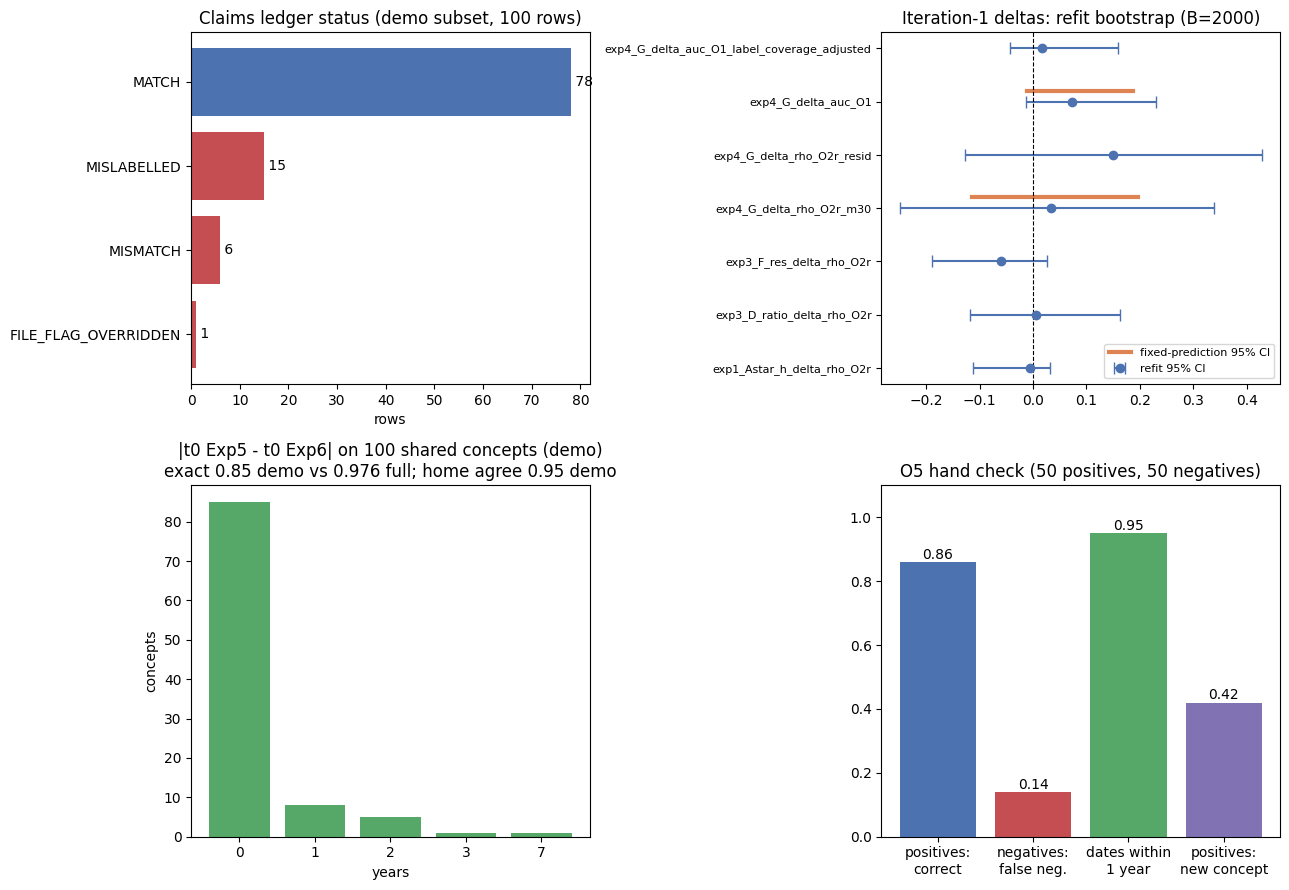

In [13]:
dsx = {d["dataset"]: d["examples"] for d in out["datasets"]}
fig, ax = plt.subplots(2, 2, figsize=(13, 9))

# 1. ledger status (demo subset)
sc = pd.Series(out["metadata"]["ledger_status_counts"]).sort_values()
ax[0, 0].barh(sc.index, sc.values, color=["#c44e52" if k != "MATCH" else "#4c72b0" for k in sc.index])
for i, v in enumerate(sc.values):
    ax[0, 0].text(v, i, f" {v}", va="center")
ax[0, 0].set_title(f"Claims ledger status (demo subset, {len(dsx['claims_ledger'])} rows)")
ax[0, 0].set_xlabel("rows")

# 2. refit bootstrap CIs for the iteration-1 deltas
t3 = out["metadata"]["t3_refit"]
y = np.arange(len(t3))
pts = [r["point_reproduced"] for r in t3]
lo = [r["ci95_refit"][0] for r in t3]
hi = [r["ci95_refit"][1] for r in t3]
ax[0, 1].errorbar(pts, y, xerr=[np.subtract(pts, lo), np.subtract(hi, pts)], fmt="o", capsize=4, color="#4c72b0", label="refit 95% CI")
fx = [(i, r["fixed_prediction_ci95"]) for i, r in enumerate(t3) if r.get("fixed_prediction_ci95")]
for i, c in fx:
    ax[0, 1].plot(c, [i + 0.2] * 2, color="#dd8452", lw=3, label="fixed-prediction 95% CI" if i == fx[0][0] else None)
ax[0, 1].axvline(0, color="k", lw=0.8, ls="--")
ax[0, 1].set_yticks(y, [r["row"] for r in t3], fontsize=8)
ax[0, 1].set_title("Iteration-1 deltas: refit bootstrap (B=2000)")
ax[0, 1].legend(fontsize=8)

# 3. onset-year agreement between Exp5 and Exp6 frames
d = np.array([e["eval_onset_abs_diff"] for e in dsx["frame_agreement_shared_concepts"]])
vals, cnt = np.unique(d, return_counts=True)
ax[1, 0].bar(vals.astype(int).astype(str), cnt, color="#55a868")
ax[1, 0].set_title(f"|t0 Exp5 - t0 Exp6| on {len(d)} shared concepts (demo)\n"
                   f"exact {np.mean(d == 0):.2f} demo vs {ma['onset_exact_agree']:.3f} full; home agree "
                   f"{np.mean([e['eval_home_agree'] for e in dsx['frame_agreement_shared_concepts']]):.2f} demo")
ax[1, 0].set_xlabel("years")
ax[1, 0].set_ylabel("concepts")

# 4. O5 hand check
hc_ex = dsx["o5_hand_check"]
pos = [e["eval_positive_correct"] for e in hc_ex if "eval_positive_correct" in e]
neg = [e["eval_false_negative"] for e in hc_ex if "eval_false_negative" in e]
bars = {"positives:\ncorrect": np.mean(pos), "negatives:\nfalse neg.": np.mean(neg),
        "dates within\n1 year": ma["o5_date_error_le1_share"], "positives:\nnew concept": out["metadata"]["o5_hand_check"]["positives_emergence_meaningful_share"]}
ax[1, 1].bar(bars.keys(), bars.values(), color=["#4c72b0", "#c44e52", "#55a868", "#8172b3"])
for i, v in enumerate(bars.values()):
    ax[1, 1].text(i, v + 0.01, f"{v:.2f}", ha="center")
ax[1, 1].set_ylim(0, 1.1)
ax[1, 1].set_title(f"O5 hand check ({len(pos)} positives, {len(neg)} negatives)")
plt.tight_layout()
plt.show()